# Assignment 3 Forecasting Methods

## Question A

In [ ]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from matplotlib.ticker import MultipleLocator
from statsmodels.tsa.api import VAR

In [ ]:
#load data: quarterly U.S. time series on GDP, CPI and Federal Funds Rate (IR) 1954Q3 -> 2024Q3  
df3 = pd.read_excel("DataAssignment3.xls", sheet_name=1)

In [67]:
df3['observation_date'] = pd.to_datetime(df3['observation_date'])
time_index = df3['observation_date']

gdp = df3['GDP']
cpi = df3['CPI']
ir  = df3['IR']

In [68]:
#log growth rates quartely
df3['log_gdp_gr']  = 100 * np.log(df3['GDP']).diff()
df3['log_cpi_infl'] = 100 * np.log(df3['CPI']).diff()

log_gdp_gr = df3['log_gdp_gr']
log_cpi_infl = df3['log_cpi_infl']

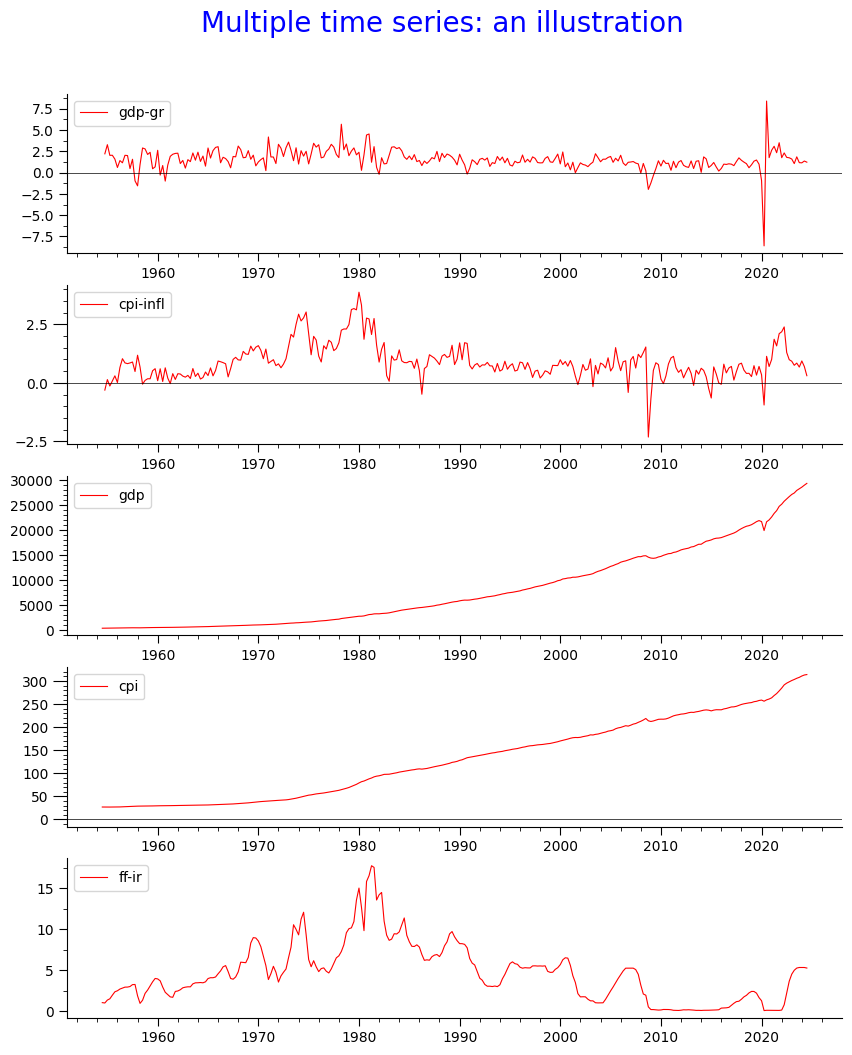

In [115]:
#plot log gdp growthrate, cpi inflation, and ir
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(10, 12), sharex=True)

# --- 1st Plot: GDP-GR ---
ax1.plot(time_index, log_gdp_gr, color='red', linewidth=0.8, label='gdp-gr')
ax1.axhline(0, color='black', linewidth=0.5)
ax1.legend(frameon=True, loc='upper left')

#y-axis
ax1.yaxis.set_major_locator(MultipleLocator(2.5))
ax1.yaxis.set_minor_locator(MultipleLocator(1.25))
ax1.tick_params(axis='y', which='major', length=6)
ax1.tick_params(axis='y', which='minor', length=3)


# --- 2nd Plot: CPI-INFL ---
ax2.plot(time_index, log_cpi_infl, color='red', linewidth=0.8, label='cpi-infl')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.legend(frameon=True, loc='upper left')

#y-axis
ax2.yaxis.set_major_locator(MultipleLocator(2.5))
ax2.yaxis.set_minor_locator(MultipleLocator(0.5))
ax2.tick_params(axis='y', which='major', length=10)
ax2.tick_params(axis='y', which='minor', length=3)

# --- 3th Plot: GDP ---
ax3.plot(time_index, gdp, color='red', linewidth=0.8, label='gdp')
ax3.legend(frameon=True, loc='upper left')

#y-axis
ax3.yaxis.set_major_locator(MultipleLocator(5000))
ax3.yaxis.set_minor_locator(MultipleLocator(1000))
ax3.tick_params(axis='y', which='major', length=6)
ax3.tick_params(axis='y', which='minor', length=3)


# --- 4th Plot: CPI ---
ax4.plot(time_index, cpi, color='red', linewidth=0.8, label='cpi')
ax4.axhline(0, color='black', linewidth=0.5)
ax4.legend(frameon=True, loc='upper left')

#y-axis
ax4.yaxis.set_major_locator(MultipleLocator(50))
ax4.yaxis.set_minor_locator(MultipleLocator(10))
ax4.tick_params(axis='y', which='major', length=10)
ax4.tick_params(axis='y', which='minor', length=3)

# --- 5th Plot: FF-IR ---
ax5.plot(time_index, ir, color='red', linewidth=0.8, label='ff-ir')
ax5.legend(frameon=True, loc='upper left')

#y-axis
ax5.yaxis.set_major_locator(MultipleLocator(5))
ax5.yaxis.set_minor_locator(MultipleLocator(2.5))
ax5.tick_params(axis='y', which='major', length=6)
ax5.tick_params(axis='y', which='minor', length=3)

#title
fig.suptitle('Multiple time series: an illustration',fontsize=20, color='blue', y=0.95)

#time
major_locator = mdates.YearLocator(10)   # decades
major_formatter = mdates.DateFormatter('%Y')
minor_locator = mdates.YearLocator(2) #every two years

for ax in (ax1, ax2, ax3, ax4, ax5):
    ax.xaxis.set_major_locator(major_locator)
    ax.xaxis.set_major_formatter(major_formatter)
    ax.xaxis.set_minor_locator(minor_locator)

    ax.tick_params(axis='x', which='major', length=6)
    ax.tick_params(axis='x', which='minor', length=3)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax1.tick_params(axis='x', labelbottom=True)
ax2.tick_params(axis='x', labelbottom=True)
ax3.tick_params(axis='x', labelbottom=True)
ax4.tick_params(axis='x', labelbottom=True)
ax5.tick_params(axis='x', labelbottom=True)

#plot
plt.subplots_adjust(hspace=0.20)
plt.show()


## Question B

In [ ]:
#gdp growth and inflation rate (log_gdp_gr, log_cpi_infl) model VAR(3)(bivariate). Include a constant term
#report estimand coefficients
#stability conditions: check eigenvalues 

In [ ]:
#drop missing values
df_b = df3[['log_gdp_gr', 'log_cpi_infl']].dropna()

In [ ]:
#model VAR(p=3)
model_b = VAR(df_b) #includes constant
results_b = model_b.fit(3) #p=3 

/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
#results: estimand coefficients
print(results_b.params) 

                 log_gdp_gr  log_cpi_infl
const              0.860859      0.028854
L1.log_gdp_gr      0.094663      0.021513
L1.log_cpi_infl    0.074566      0.522367
L2.log_gdp_gr      0.165903      0.050111
L2.log_cpi_infl   -0.059133     -0.012757
L3.log_gdp_gr      0.024143      0.042061
L3.log_cpi_infl    0.248576      0.264066


In [78]:
#results: stability
eigvals = results_b.roots
print(eigvals)

[ 8.30296757-0.j          2.9315233 -0.j         -2.86741579-0.j
 -0.62889351+1.66442799j -0.62889351-1.66442799j  1.10923867-0.j        ]


In [82]:
if np.all(eigvals) < 1:
    print('VAR is stable.')
else:
    print('VAR is not stable')

VAR is not stable


## Question C

In [ ]:
#pre-sample values for NaN values: fair comparison
pre_sample = 5
df_b_est = df_b.iloc[pre_sample:]

#AIC 
p_array = [1,2,3,4,5]
aic_values = {}

for p in p_array:
    model = VAR(df_b_est)
    results = model.fit(p)
    aic_values[p] = results.aic

/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packag

In [85]:
#results
for p, aic in aic_values.items():
    print(f"p = {p}: AIC = {aic:.4f}")

best_p = min(aic_values, key=aic_values.get)
print(f"\nBest model (AIC) = VAR({best_p})")

p = 1: AIC = -1.2135
p = 2: AIC = -1.2371
p = 3: AIC = -1.3008
p = 4: AIC = -1.2726
p = 5: AIC = -1.2643

Best model (AIC) = VAR(3)


## Question D

In [86]:
#best model: model_b but now without first 5 samples

model_best = VAR(df_b_est)
results_best = model_best.fit(best_p)

/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [87]:
#forecast h=1,2,3,4
h = 4
forecasts = results_best.forecast(df_b_est.values[-best_p:], steps=h)

forecast_index = range(1, h+1)
forecast_df = pd.DataFrame(forecasts, columns=df_b_est.columns, index=forecast_index)
print(forecast_df)

   log_gdp_gr  log_cpi_infl
1    1.442497      0.567363
2    1.432652      0.652856
3    1.357034      0.596404
4    1.408808      0.642331


In [89]:
#95% CI
forecast_ci = results_best.forecast_interval(df_b_est.values[-best_p:], steps=h)
lower, forecast, upper = forecast_ci

ci_lower_df = pd.DataFrame(lower, columns=df_b_est.columns, index=forecast_index)
ci_upper_df = pd.DataFrame(upper, columns=df_b_est.columns, index=forecast_index)

for var in df_b_est.columns:
    print(f"\nVariable: {var}")
    for i in range(h):
        print(f"Step {i+1}: [{ci_lower_df[var].iloc[i]:.4f}, {ci_upper_df[var].iloc[i]:.4f}]")


Variable: log_gdp_gr
Step 1: [1.4425, 3.7356]
Step 2: [1.4327, 3.7395]
Step 3: [1.3570, 3.6978]
Step 4: [1.4088, 3.7692]

Variable: log_cpi_infl
Step 1: [0.5674, 1.4798]
Step 2: [0.6529, 1.6914]
Step 3: [0.5964, 1.6846]
Step 4: [0.6423, 1.8274]


## Question E

In [90]:
#pre-sample values for NaN values: fair comparison
df_e = df_b.iloc[:-20]
df_e_est = df_e.iloc[pre_sample:]

### Question C

In [91]:
#AIC 
p_array = [1,2,3,4,5]
aic_values_e = {}

for p in p_array:
    model = VAR(df_e_est)
    results = model.fit(p)
    aic_values_e[p] = results.aic

/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packag

In [92]:
#results
for p, aic in aic_values_e.items():
    print(f"p = {p}: AIC = {aic:.4f}")

best_p_e = min(aic_values_e, key=aic_values_e.get)
print(f"\nBest model (AIC) = VAR({best_p_e})")

p = 1: AIC = -1.8351
p = 2: AIC = -1.8625
p = 3: AIC = -1.9448
p = 4: AIC = -1.9353
p = 5: AIC = -1.9291

Best model (AIC) = VAR(3)


### Question D

In [93]:
#best model
model_best_e = VAR(df_e_est)
results_best_e = model_best.fit(best_p_e)

/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [94]:
#forecast h=1,2,3,4
forecasts_e = results_best_e.forecast(df_e_est.values[-best_p_e:], steps=h)

forecast_index_e = range(1, h+1)
forecast_df_e = pd.DataFrame(forecasts_e, columns=df_e_est.columns, index=forecast_index_e)
print(forecast_df_e)

   log_gdp_gr  log_cpi_infl
1    1.292603      0.399746
2    1.453818      0.584114
3    1.351788      0.572609
4    1.369065      0.581217


In [96]:
#95% CI
forecast_ci_e = results_best_e.forecast_interval(df_e_est.values[-best_p_e:], steps=h)
lower_e, forecast_e, upper_e = forecast_ci_e

ci_lower_df_e = pd.DataFrame(lower_e, columns=df_e_est.columns, index=forecast_index_e)
ci_upper_df_e = pd.DataFrame(upper_e, columns=df_e_est.columns, index=forecast_index_e)

for var in df_e_est.columns:
    print(f"\nVariable: {var}")
    for i in range(h):
        print(f"Step {i+1}: [{ci_lower_df_e[var].iloc[i]:.4f}, {ci_upper_df_e[var].iloc[i]:.4f}]")


Variable: log_gdp_gr
Step 1: [1.2926, 3.5857]
Step 2: [1.4538, 3.7606]
Step 3: [1.3518, 3.6925]
Step 4: [1.3691, 3.7294]

Variable: log_cpi_infl
Step 1: [0.3997, 1.3122]
Step 2: [0.5841, 1.6226]
Step 3: [0.5726, 1.6608]
Step 4: [0.5812, 1.7663]


## Question F

In [97]:
df_f = df3[['log_gdp_gr', 'log_cpi_infl', 'IR']].dropna()

In [98]:
#model VAR(p=2)
model_f = VAR(df_f) #includes constant
results_f = model_f.fit(2) #p=2 

/Users/fellabouznad/anaconda3/envs/deepl/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [100]:
#results: estimand coefficients
print(results_f.params) 

                 log_gdp_gr  log_cpi_infl        IR
const              0.959271      0.144054 -0.113739
L1.log_gdp_gr      0.082891     -0.000475  0.173948
L1.log_cpi_infl    0.074044      0.502833 -0.249254
L1.IR              0.112511      0.158675  1.166592
L2.log_gdp_gr      0.129870      0.001972  0.066377
L2.log_cpi_infl    0.117768      0.181711  0.344077
L2.IR             -0.096212     -0.130183 -0.237641


In [101]:
#forecast h=1,2,3,4
forecasts_f = results_f.forecast(df_f.values[-2:], steps=h)

forecast_index_f = range(1, h+1)
forecast_df_f = pd.DataFrame(forecasts_f, columns=df_f.columns, index=forecast_index_e)
print(forecast_df_f)

   log_gdp_gr  log_cpi_infl        IR
1    1.421700      0.566672  5.227214
2    1.395934      0.630201  5.025587
3    1.435529      0.682989  4.881960
4    1.450094      0.724465  4.776199


In [103]:
#95% CI
forecast_ci_f = results_f.forecast_interval(df_f.values[-2:], steps=h)
lower_f, forecast_f, upper_f = forecast_ci_f

ci_lower_df_f = pd.DataFrame(lower_f, columns=df_f.columns, index=forecast_index_f)
ci_upper_df_f = pd.DataFrame(upper_f, columns=df_f.columns, index=forecast_index_f)

for var in df_f.columns:
    print(f"\nVariable: {var}")
    for i in range(h):
        print(f"Step {i+1}: [{ci_lower_df_f[var].iloc[i]:.4f}, {ci_upper_df_f[var].iloc[i]:.4f}]")


Variable: log_gdp_gr
Step 1: [1.4217, 3.7002]
Step 2: [1.3959, 3.6969]
Step 3: [1.4355, 3.7803]
Step 4: [1.4501, 3.8051]

Variable: log_cpi_infl
Step 1: [0.5667, 1.4845]
Step 2: [0.6302, 1.7096]
Step 3: [0.6830, 1.8676]
Step 4: [0.7245, 1.9804]

Variable: IR
Step 1: [5.2272, 6.7433]
Step 2: [5.0256, 7.4322]
Step 3: [4.8820, 7.9770]
Step 4: [4.7762, 8.4377]
